# EDA Telehealth — Subplots com Escalas Padronizadas (estilo 1ESPA)

Este notebook gera **subplots por família** com **mesma escala no eixo Y** entre gráficos comparáveis.
Somente `matplotlib` (sem seaborn), títulos padronizados, legendas claras e **cálculos explícitos** de limites de eixo.

**Famílias:**
1. Evolução temporal (Nacional; Rural vs. Urbano)
2. Distribuições (Histograma; Boxplot RUCA)
3. Demografia (Idade; Sexo; Raça/Etnia)
4. Status (Dual vs. Only; Aged/Disabled/ESRD)
5. Rankings estaduais (Top 10; Bottom 10)
6. Correlação (heatmap)

> Observação: caminhos e nomes seguem o CSV fornecido: `Medicare_Telehealth_Trends_Q1_2025.csv`.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve, auc, precision_recall_fscore_support, confusion_matrix, precision_score, recall_score

from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve



In [34]:
# === Config visual base ===
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

def to_percent(x, pos):
    """Formata valores decimais (0.123) como porcentagem ('12%')."""
    return f"{x*100:.0f}%"

def apply_percent_axis(ax):
    """Aplica formatação percentual no eixo Y."""
    ax.yaxis.set_major_formatter(FuncFormatter(to_percent))

def ceil_to_step(value, step=0.05):
    """Arredonda 'value' para cima ao múltiplo de 'step' mais próximo.
    Ex.: ceil_to_step(0.267, 0.05) -> 0.30
    """
    if value <= 0:
        return step
    k = int(np.ceil(value / step))
    return k * step


In [17]:

CSV_PATH = Path('./Medicare_Telehealth_Trends_Q1_2025.csv')  # ajuste se necessário
df = pd.read_csv(CSV_PATH)

# Tipos numéricos
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['quarter'] = pd.to_numeric(df['quarter'].astype(str).str.replace('Q','', regex=False), errors='coerce')
for c in ['Pct_Telehealth','Total_Bene_Telehealth','Total_PartB_Enrl','Total_Bene_TH_Elig']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Filtra linhas válidas e cria período
df = df.dropna(subset=['Year','quarter','Pct_Telehealth']).copy()
df['Year'] = df['Year'].astype(int)
df['quarter'] = df['quarter'].astype(int)
df['period'] = df['Year'].astype(str) + '-Q' + df['quarter'].astype(str)

# Slices úteis
NAT_ALL = (df['Bene_Geo_Desc']=='National') & (df['Bene_RUCA_Desc']=='All') &           (df['Bene_Mdcd_Mdcr_Enrl_Stus']=='All') & (df['Bene_Mdcr_Entlmt_Stus']=='All') &           (df['Bene_Race_Desc']=='All') & (df['Bene_Sex_Desc']=='All') & (df['Bene_Age_Desc']=='All')

nat = df[NAT_ALL].copy().sort_values(['Year','quarter'])

latest_year = int(nat['Year'].max())
latest_q = int(nat[nat['Year'].eq(latest_year)]['quarter'].max())

states_all = df[df['Bene_Geo_Desc']!='National'].copy()
print({'latest_year': latest_year, 'latest_q': latest_q, 'rows': len(df)})


{'latest_year': 2025, 'latest_q': 1, 'rows': 22547}


## Família 1 — Evolução temporal (mesma escala entre subplots)

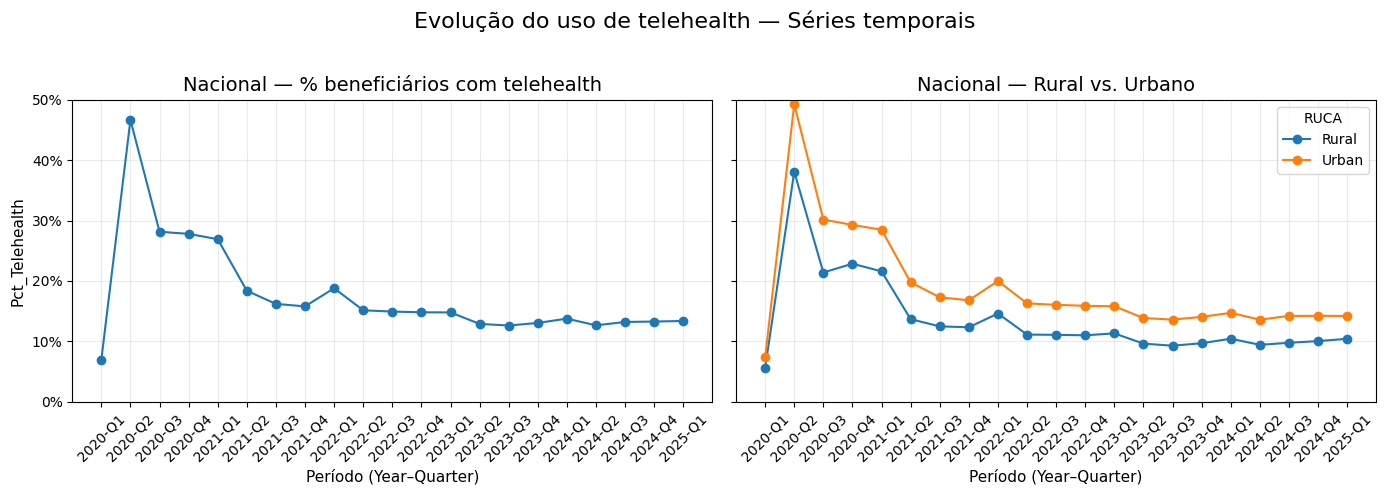

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
fig.suptitle('Evolução do uso de telehealth — Séries temporais', fontsize=16)

# 1.1 Nacional
ax = axes[0]
y1 = nat['Pct_Telehealth'].to_numpy()
ax.plot(nat['period'], y1, marker='o')
ax.set_title('Nacional — % beneficiários com telehealth')
ax.set_xlabel('Período (Year–Quarter)')
ax.set_ylabel('Pct_Telehealth')
for t in ax.get_xticklabels(): t.set_rotation(45)

# 1.2 Rural vs Urbano (Nacional)
ax = axes[1]
ru = df[(df['Bene_Geo_Desc']=='National') & (df['Bene_RUCA_Desc'].isin(['Rural','Urban'])) &
        (df['Bene_Mdcd_Mdcr_Enrl_Stus']=='All') & (df['Bene_Mdcr_Entlmt_Stus']=='All') &
        (df['Bene_Race_Desc']=='All') & (df['Bene_Sex_Desc']=='All') & (df['Bene_Age_Desc']=='All')].copy()
ru = ru.sort_values(['Bene_RUCA_Desc','Year','quarter'])

# prepara y para escala
y2_vals = []
for grp, sub in ru.groupby('Bene_RUCA_Desc'):
    y = sub['Pct_Telehealth'].to_numpy()
    y2_vals.append(y)
    ax.plot(sub['period'], y, marker='o', label=grp)
ax.set_title('Nacional — Rural vs. Urbano')
ax.set_xlabel('Período (Year–Quarter)')
for t in ax.get_xticklabels(): t.set_rotation(45)
ax.legend(title='RUCA', loc='best')

# === ESCALA COMPARTILHADA (explícita) ===
ymax_candidates = [y1.max()] + [v.max() for v in y2_vals]
y_max = float(np.max(ymax_candidates))
y_lim = ceil_to_step(y_max, step=0.05)   # arredonda para cima no múltiplo de 5 p.p.
for ax in axes:
    ax.set_ylim(0.0, y_lim)
    apply_percent_axis(ax)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


## Família 2 — Distribuições (histograma; boxplot RUCA)

C:\Users\Gustavo\AppData\Local\Temp\ipykernel_8364\3583258050.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_box, labels=labels)


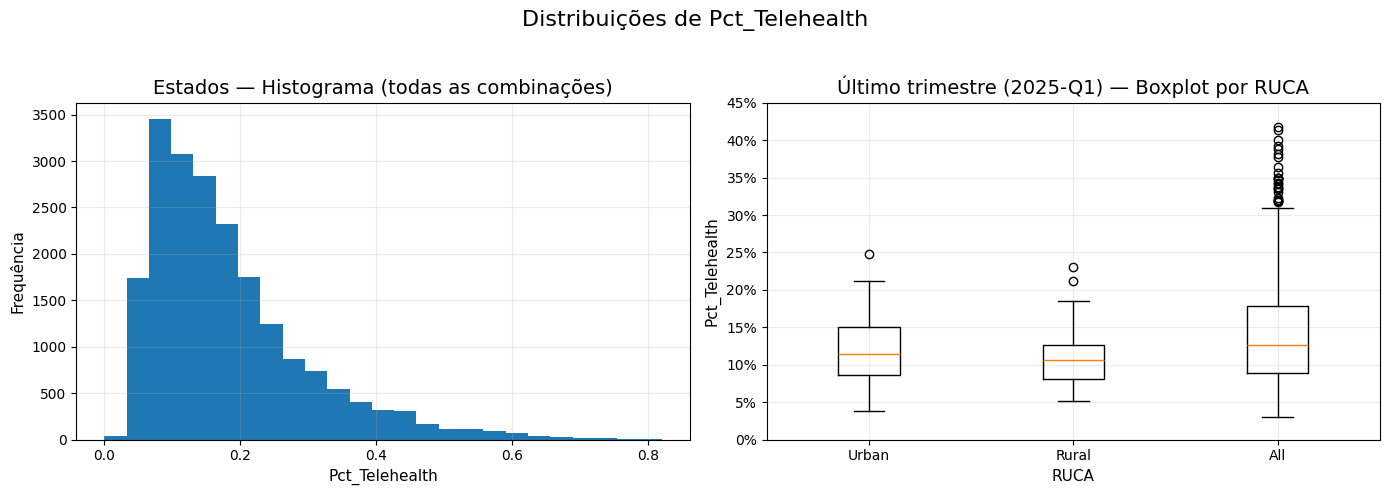

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=False)
fig.suptitle('Distribuições de Pct_Telehealth', fontsize=16)

# 2.1 Histograma global (estados)
ax = axes[0]
vals = states_all['Pct_Telehealth'].dropna().to_numpy()
ax.hist(vals, bins=25)
ax.set_title('Estados — Histograma (todas as combinações)')
ax.set_xlabel('Pct_Telehealth'); ax.set_ylabel('Frequência')

# 2.2 Boxplot RUCA (último trimestre, estados)
ax = axes[1]
last_ru = states_all[(states_all['Year']==latest_year) & (states_all['quarter']==latest_q)]
ordered = ['Urban','Rural','All','Unknown']
labels, data_box = [], []
for k in ordered:
    mask = (last_ru['Bene_RUCA_Desc']==k)
    if mask.any():
        labels.append(k)
        data_box.append(last_ru.loc[mask, 'Pct_Telehealth'].dropna().to_numpy())

ax.boxplot(data_box, labels=labels)
ax.set_title(f'Último trimestre ({latest_year}-Q{latest_q}) — Boxplot por RUCA')
ax.set_xlabel('RUCA'); ax.set_ylabel('Pct_Telehealth')

# Escala do boxplot em % (histograma mantém contagem)
max_box = max([d.max() if len(d)>0 else 0 for d in data_box]) if data_box else 0.0
ylim = ceil_to_step(float(max_box), step=0.05)
ax.set_ylim(0.0, ylim)
apply_percent_axis(ax)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


## Família 3 — Demografia (idade; sexo; raça/etnia) — mesma escala

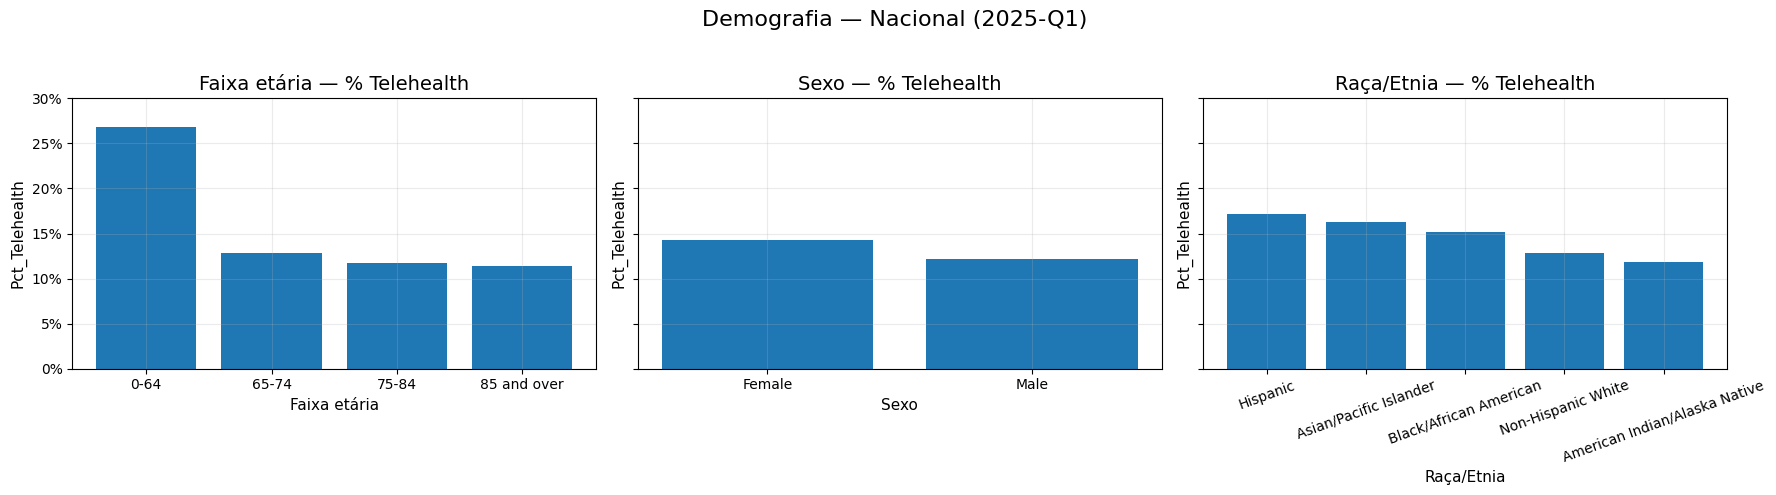

In [20]:

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)
fig.suptitle(f'Demografia — Nacional ({latest_year}-Q{latest_q})', fontsize=16)

# 3.1 Idade
ax = axes[0]
age_order = ['0-64','65-74','75-84','85 and over']
age = df[(df['Bene_Geo_Desc']=='National') & (df['Bene_RUCA_Desc']=='All') &
         (df['Bene_Mdcd_Mdcr_Enrl_Stus']=='All') & (df['Bene_Mdcr_Entlmt_Stus']=='All') &
         (df['Bene_Race_Desc']=='All') & (df['Bene_Sex_Desc']=='All') &
         (df['Year']==latest_year) & (df['quarter']==latest_q) & (df['Bene_Age_Desc']!='All')
        ][['Bene_Age_Desc','Pct_Telehealth']]
age = age.set_index('Bene_Age_Desc').reindex(age_order).reset_index()
y_age = age['Pct_Telehealth'].to_numpy()
ax.bar(age['Bene_Age_Desc'], y_age)
ax.set_title('Faixa etária — % Telehealth')
ax.set_xlabel('Faixa etária'); ax.set_ylabel('Pct_Telehealth')

# 3.2 Sexo
ax = axes[1]
sex_order = ['Female','Male']
sex = df[(df['Bene_Geo_Desc']=='National') & (df['Bene_RUCA_Desc']=='All') &
         (df['Bene_Mdcd_Mdcr_Enrl_Stus']=='All') & (df['Bene_Mdcr_Entlmt_Stus']=='All') &
         (df['Bene_Race_Desc']=='All') & (df['Bene_Age_Desc']=='All') &
         (df['Year']==latest_year) & (df['quarter']==latest_q) & (df['Bene_Sex_Desc']!='All')
        ][['Bene_Sex_Desc','Pct_Telehealth']]
sex = sex.set_index('Bene_Sex_Desc').reindex(sex_order).reset_index()
y_sex = sex['Pct_Telehealth'].to_numpy()
ax.bar(sex['Bene_Sex_Desc'], y_sex)
ax.set_title('Sexo — % Telehealth'); ax.set_xlabel('Sexo'); ax.set_ylabel('Pct_Telehealth')

# 3.3 Raça/Etnia
ax = axes[2]
race_order = ['Hispanic','Asian/Pacific Islander','Black/African American',
              'Non-Hispanic White','American Indian/Alaska Native']
race = df[(df['Bene_Geo_Desc']=='National') & (df['Bene_RUCA_Desc']=='All') &
          (df['Bene_Mdcd_Mdcr_Enrl_Stus']=='All') & (df['Bene_Mdcr_Entlmt_Stus']=='All') &
          (df['Bene_Sex_Desc']=='All') & (df['Bene_Age_Desc']=='All') &
          (df['Year']==latest_year) & (df['quarter']==latest_q) & (df['Bene_Race_Desc']!='All')
         ][['Bene_Race_Desc','Pct_Telehealth']]
race = race.set_index('Bene_Race_Desc').reindex(race_order).reset_index()
y_race = race['Pct_Telehealth'].to_numpy()
ax.bar(race['Bene_Race_Desc'], y_race)
ax.set_title('Raça/Etnia — % Telehealth'); ax.set_xlabel('Raça/Etnia'); ax.set_ylabel('Pct_Telehealth')
for t in ax.get_xticklabels(): t.set_rotation(20)

# === ESCALA COMPARTILHADA (explícita) ===
max_demog = float(np.max([np.nanmax(y_age), np.nanmax(y_sex), np.nanmax(y_race)]))
ylim = ceil_to_step(max_demog, step=0.05)
for ax in axes:
    ax.set_ylim(0.0, ylim)
    apply_percent_axis(ax)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


## Família 4 — Status (Dual vs Only; Elegibilidade) — mesma escala

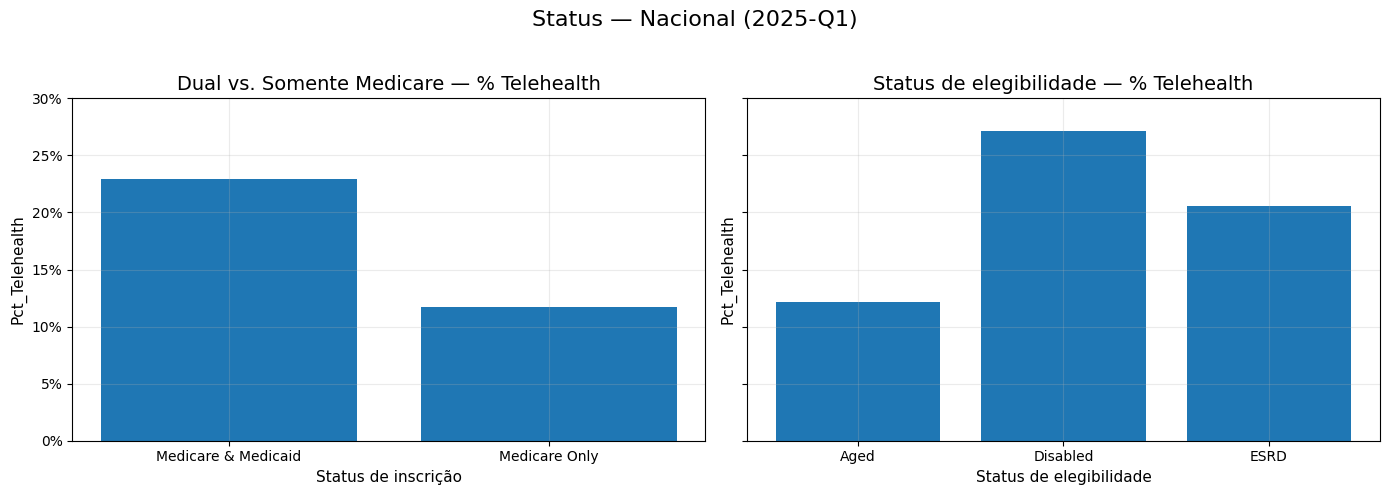

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
fig.suptitle(f'Status — Nacional ({latest_year}-Q{latest_q})', fontsize=16)

# 4.1 Dual vs Only
ax = axes[0]
dual_order = ['Medicare & Medicaid','Medicare Only']
dual = df[(df['Bene_Geo_Desc']=='National') & (df['Bene_RUCA_Desc']=='All') &
          (df['Bene_Mdcd_Mdcr_Enrl_Stus'].isin(dual_order)) &
          (df['Bene_Mdcr_Entlmt_Stus']=='All') & (df['Bene_Race_Desc']=='All') &
          (df['Bene_Sex_Desc']=='All') & (df['Bene_Age_Desc']=='All') &
          (df['Year']==latest_year) & (df['quarter']==latest_q)
         ][['Bene_Mdcd_Mdcr_Enrl_Stus','Pct_Telehealth']]
dual = dual.set_index('Bene_Mdcd_Mdcr_Enrl_Stus').reindex(dual_order).reset_index()
y_dual = dual['Pct_Telehealth'].to_numpy()
ax.bar(dual['Bene_Mdcd_Mdcr_Enrl_Stus'], y_dual)
ax.set_title('Dual vs. Somente Medicare — % Telehealth')
ax.set_xlabel('Status de inscrição'); ax.set_ylabel('Pct_Telehealth')

# 4.2 Elegibilidade
ax = axes[1]
ent_order = ['Aged','Disabled','ESRD']
ent = df[(df['Bene_Geo_Desc']=='National') & (df['Bene_RUCA_Desc']=='All') &
         (df['Bene_Mdcd_Mdcr_Enrl_Stus']=='All') & (df['Bene_Mdcr_Entlmt_Stus']!='All') &
         (df['Bene_Race_Desc']=='All') & (df['Bene_Sex_Desc']=='All') & (df['Bene_Age_Desc']=='All') &
         (df['Year']==latest_year) & (df['quarter']==latest_q)
        ][['Bene_Mdcr_Entlmt_Stus','Pct_Telehealth']]
ent = ent.set_index('Bene_Mdcr_Entlmt_Stus').reindex(ent_order).reset_index()
y_ent = ent['Pct_Telehealth'].to_numpy()
ax.bar(ent['Bene_Mdcr_Entlmt_Stus'], y_ent)
ax.set_title('Status de elegibilidade — % Telehealth')
ax.set_xlabel('Status de elegibilidade'); ax.set_ylabel('Pct_Telehealth')

# === ESCALA COMPARTILHADA (explícita) ===
max_status = float(np.max([np.nanmax(y_dual), np.nanmax(y_ent)]))
ylim = ceil_to_step(max_status, step=0.05)
for ax in axes:
    ax.set_ylim(0.0, ylim)
    apply_percent_axis(ax)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


## Família 5 — Rankings estaduais (Top 10; Bottom 10) — mesma escala

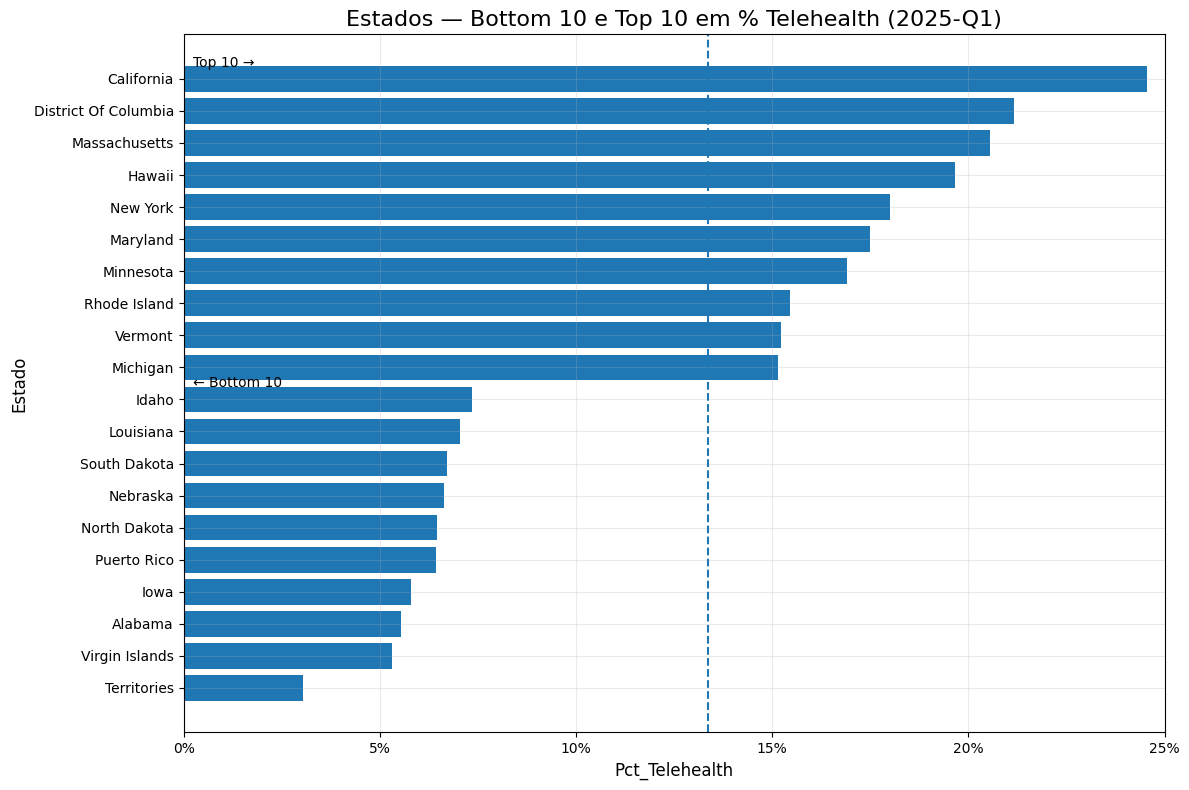

In [22]:
# Último trimestre disponível (baseado na série nacional "All")
last_year = int(df.loc[df["Bene_Geo_Desc"] == "National", "Year"].max())
last_q = int(df[(df["Bene_Geo_Desc"] == "National") & (df["Year"] == last_year)]["quarter"].max())

mask_latest = (
    (df["Bene_Geo_Desc"] != "National")
    & (df["Year"] == last_year)
    & (df["quarter"] == last_q)
    & (df["Bene_RUCA_Desc"] == "All")
    & (df["Bene_Mdcd_Mdcr_Enrl_Stus"] == "All")
    & (df["Bene_Mdcr_Entlmt_Stus"] == "All")
    & (df["Bene_Race_Desc"] == "All")
    & (df["Bene_Sex_Desc"] == "All")
    & (df["Bene_Age_Desc"] == "All")
)
state_latest = df.loc[mask_latest, ["Bene_Geo_Desc", "Pct_Telehealth"]].copy()

# Top 10 e Bottom 10
top10 = state_latest.nlargest(10, "Pct_Telehealth").copy()
top10["Grupo"] = "Top 10"
bot10 = state_latest.nsmallest(10, "Pct_Telehealth").copy()
bot10["Grupo"] = "Bottom 10"

# Combina e ordena (da menor para a maior para facilitar leitura)
combo = pd.concat([bot10, top10], ignore_index=True).sort_values("Pct_Telehealth", ascending=True)

# ---- Plot único ----
plt.rcParams.update({
    "figure.figsize": (12, 8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
bars = ax.barh(combo["Bene_Geo_Desc"], combo["Pct_Telehealth"])

ax.set_title(f"Estados — Bottom 10 e Top 10 em % Telehealth ({last_year}-Q{last_q})")
ax.set_xlabel("Pct_Telehealth")
ax.set_ylabel("Estado")

# Escala explícita (múltiplo de 5 p.p.)
xmax = float(combo["Pct_Telehealth"].max())
xlim = ceil_to_step(xmax, step=0.05)
ax.set_xlim(0, xlim)
ax.xaxis.set_major_formatter(FuncFormatter(to_percent))

# Linha guia: média nacional no mesmo período
nat_mask = (
    (df["Bene_Geo_Desc"] == "National")
    & (df["Bene_RUCA_Desc"] == "All")
    & (df["Bene_Mdcd_Mdcr_Enrl_Stus"] == "All")
    & (df["Bene_Mdcr_Entlmt_Stus"] == "All")
    & (df["Bene_Race_Desc"] == "All")
    & (df["Bene_Sex_Desc"] == "All")
    & (df["Bene_Age_Desc"] == "All")
    & (df["Year"] == last_year)
    & (df["quarter"] == last_q)
)
nat_pct = float(df.loc[nat_mask, "Pct_Telehealth"].iloc[0])
ax.axvline(nat_pct, linestyle="--")

# Anotações simples indicando a faixa Bottom 10 / Top 10
first_top_idx = combo[combo["Grupo"] == "Top 10"].index.min()
ax.text(0.01 * xlim, (first_top_idx - 0.5), "← Bottom 10", va="center")
ax.text(0.01 * xlim, (combo.index.max() + 0.5), "Top 10 →", va="center", ha="left")

plt.tight_layout()
plt.show()

## Família 6 — Heatmap de Correlação (numéricas)

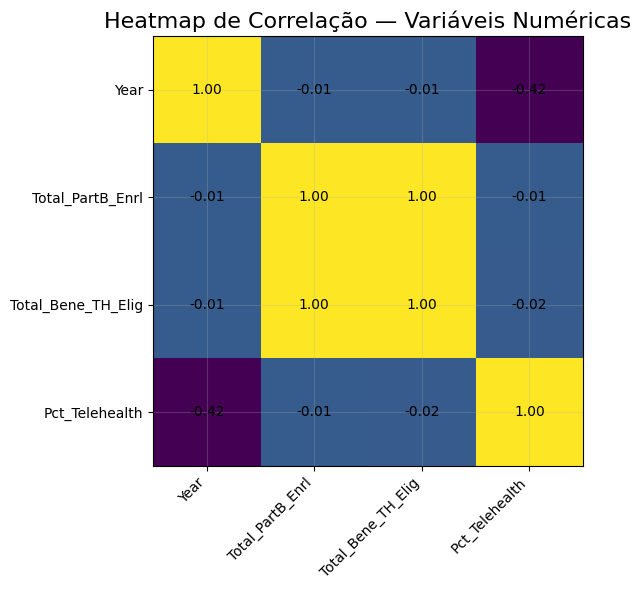

In [23]:

num_df = df[['Year','Total_PartB_Enrl','Total_Bene_TH_Elig','Pct_Telehealth']].dropna()
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr.values, interpolation='nearest')
plt.title('Heatmap de Correlação — Variáveis Numéricas')
plt.xticks(range(corr.shape[1]), corr.columns, rotation=45, ha='right')
plt.yticks(range(corr.shape[0]), corr.columns)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j, i, f"{corr.values[i,j]:.2f}", ha='center', va='center')
plt.tight_layout()
plt.show()


## (Opcional) KPIs de gaps — cálculos explícitos no último trimestre

In [24]:

from math import isnan

def get_pct(filter_dict):
    m = pd.Series(True, index=df.index)
    for col, val in filter_dict.items():
        m &= (df[col]==val)
    row = df[m & (df['Year']==latest_year) & (df['quarter']==latest_q)]
    if row.empty: return np.nan
    return float(row['Pct_Telehealth'].iloc[0])

# Urbano - Rural
p_urban = get_pct({'Bene_Geo_Desc':'National','Bene_RUCA_Desc':'Urban','Bene_Mdcd_Mdcr_Enrl_Stus':'All','Bene_Mdcr_Entlmt_Stus':'All','Bene_Race_Desc':'All','Bene_Sex_Desc':'All','Bene_Age_Desc':'All'})
p_rural = get_pct({'Bene_Geo_Desc':'National','Bene_RUCA_Desc':'Rural','Bene_Mdcd_Mdcr_Enrl_Stus':'All','Bene_Mdcr_Entlmt_Stus':'All','Bene_Race_Desc':'All','Bene_Sex_Desc':'All','Bene_Age_Desc':'All'})
gap_ru = (p_urban - p_rural) if (not isnan(p_urban) and not isnan(p_rural)) else np.nan

# Dual - Only
p_dual = get_pct({'Bene_Geo_Desc':'National','Bene_RUCA_Desc':'All','Bene_Mdcd_Mdcr_Enrl_Stus':'Medicare & Medicaid','Bene_Mdcr_Entlmt_Stus':'All','Bene_Race_Desc':'All','Bene_Sex_Desc':'All','Bene_Age_Desc':'All'})
p_only = get_pct({'Bene_Geo_Desc':'National','Bene_RUCA_Desc':'All','Bene_Mdcd_Mdcr_Enrl_Stus':'Medicare Only','Bene_Mdcr_Entlmt_Stus':'All','Bene_Race_Desc':'All','Bene_Sex_Desc':'All','Bene_Age_Desc':'All'})
gap_dual = (p_dual - p_only) if (not isnan(p_dual) and not isnan(p_only)) else np.nan

# 0–64 - 85+
p_064 = get_pct({'Bene_Geo_Desc':'National','Bene_RUCA_Desc':'All','Bene_Mdcd_Mdcr_Enrl_Stus':'All','Bene_Mdcr_Entlmt_Stus':'All','Bene_Race_Desc':'All','Bene_Sex_Desc':'All','Bene_Age_Desc':'0-64'})
p_85p = get_pct({'Bene_Geo_Desc':'National','Bene_RUCA_Desc':'All','Bene_Mdcd_Mdcr_Enrl_Stus':'All','Bene_Mdcr_Entlmt_Stus':'All','Bene_Race_Desc':'All','Bene_Sex_Desc':'All','Bene_Age_Desc':'85 and over'})
gap_age = (p_064 - p_85p) if (not isnan(p_064) and not isnan(p_85p)) else np.nan

kpis = pd.DataFrame({
    'KPI': ['Urbano - Rural', 'Dual - Only', '0–64 - 85+'],
    'Gap (p.p.)': [round(gap_ru*100, 2) if pd.notna(gap_ru) else np.nan,
                   round(gap_dual*100, 2) if pd.notna(gap_dual) else np.nan,
                   round(gap_age*100, 2) if pd.notna(gap_age) else np.nan]
})
kpis


,KPI,Gap (p.p.)
0,Urbano - Rural,3.79
1,Dual - Only,11.24
2,0–64 - 85+,15.43


In [25]:
# === 1) Rótulo "Alta adoção" (top 25% por trimestre) — estado; demais dimensões = "All" ===

# Base: estado × trimestre com demais dimensões em 'All'
base = df[
    (df['Bene_Geo_Desc']!='National') &
    (df['Bene_RUCA_Desc']=='All') &
    (df['Bene_Mdcd_Mdcr_Enrl_Stus']=='All') &
    (df['Bene_Mdcr_Entlmt_Stus']=='All') &
    (df['Bene_Race_Desc']=='All') &
    (df['Bene_Sex_Desc']=='All') &
    (df['Bene_Age_Desc']=='All')
].copy()

# Target binário: 1 se Pct_Telehealth >= Q3 do trimestre; 0 caso contrário
def label_top25(group):
    q75 = group['Pct_Telehealth'].quantile(0.75)
    return (group['Pct_Telehealth'] >= q75).astype(int)

base['y'] = base.groupby(['Year','quarter'], group_keys=False).apply(label_top25)

# Features explícitas
# - taxa de elegibilidade
base['elig_rate'] = base['Total_Bene_TH_Elig'] / base['Total_PartB_Enrl']

# - lag de Pct_Telehealth (1 trimestre) por estado
base = base.sort_values(['Bene_Geo_Desc','Year','quarter'])
base['pct_lag1'] = base.groupby('Bene_Geo_Desc')['Pct_Telehealth'].shift(1)

# Remove linhas sem lag/sem taxa
base = base.dropna(subset=['pct_lag1','elig_rate']).reset_index(drop=True)

print(base[['Bene_Geo_Desc','Year','quarter','Pct_Telehealth','elig_rate','pct_lag1','y']].head())



  Bene_Geo_Desc  Year  quarter  Pct_Telehealth  elig_rate  pct_lag1  y
0       Alabama  2020        2          0.3798   0.723084    0.0554  0
1       Alabama  2020        3          0.2346   0.766333    0.3798  0
2       Alabama  2020        4          0.2056   0.761385    0.2346  0
3       Alabama  2021        1          0.1936   0.770778    0.2056  0
4       Alabama  2021        2          0.1093   0.780618    0.1936  0


C:\Users\Gustavo\AppData\Local\Temp\ipykernel_8364\885117747.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  base['y'] = base.groupby(['Year','quarter'], group_keys=False).apply(label_top25)


In [26]:
# === 2) Split temporal (treino/validação/teste) ===

# Treino: 2020–2023 | Validação: 2024 | Teste: 2025-Q1
train = base[(base['Year']>=2020) & (base['Year']<=2023)]
valid = base[(base['Year']==2024)]
test  = base[(base['Year']==2025) & (base['quarter']==1)]

features = ['Year','quarter','elig_rate','pct_lag1']
X_train, y_train = train[features], train['y']
X_valid, y_valid = valid[features], valid['y']
X_test,  y_test  = test[features],  test['y']

print({ 'X_train': X_train.shape, 'X_valid': X_valid.shape, 'X_test': X_test.shape })


{'X_train': (810, 4), 'X_valid': (216, 4), 'X_test': (54, 4)}


In [29]:
# === 3) Modelos — Regressão Logística (L1/L2) e SVM RBF ===

# Pipeline Logística
logit = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', class_weight='balanced', max_iter=200))
])
param_logit = {
    'clf__penalty': ['l1','l2'],
    'clf__C': [0.01, 0.1, 1, 10, 100]
}

gs_logit = GridSearchCV(logit, param_logit, cv=5, scoring='roc_auc', n_jobs=-1)
gs_logit.fit(X_train, y_train)
best_logit = gs_logit.best_estimator_
print("Melhor Logística:", gs_logit.best_params_, "AUC(cv)=", round(gs_logit.best_score_, 4))

# Pipeline SVM RBF
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', probability=True, class_weight='balanced'))
])
param_svm = {
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 0.1, 0.01]
}

gs_svm = GridSearchCV(svm, param_svm, cv=5, scoring='roc_auc', n_jobs=-1)
gs_svm.fit(X_train, y_train)
best_svm = gs_svm.best_estimator_
print("Melhor SVM:", gs_svm.best_params_, "AUC(cv)=", round(gs_svm.best_score_, 4))



Melhor Logística: {'clf__C': 10, 'clf__penalty': 'l2'} AUC(cv)= 0.8445
Melhor SVM: {'clf__C': 10, 'clf__gamma': 'scale'} AUC(cv)= 0.9688


In [31]:
# === 4) Avaliação na validação + escolha de limiar pelo F1 ===

def evaluate(model, X, y, name='model', thr=None):
    proba = model.predict_proba(X)[:,1]
    auc = roc_auc_score(y, proba)
    ap  = average_precision_score(y, proba)
    # threshold ótimo para F1, se não informado
    if thr is None:
        thr_grid = np.linspace(0.1, 0.9, 17)
        f1s = [f1_score(y, (proba>=t).astype(int)) for t in thr_grid]
        thr = float(thr_grid[int(np.argmax(f1s))])
    yhat = (proba >= thr).astype(int)
    f1 = f1_score(y, yhat)
    return {'model': name, 'AUC': auc, 'AP': ap, 'F1': f1, 'thr': thr, 'proba': proba, 'yhat': yhat}

res_logit = evaluate(best_logit, X_valid, y_valid, name='Logit')
res_svm   = evaluate(best_svm,   X_valid, y_valid, name='SVM-RBF')

print(res_logit)
print(res_svm)

winner = res_logit if res_logit['AUC'] >= res_svm['AUC'] else res_svm
chosen_model = best_logit if winner['model']=='Logit' else best_svm
chosen_thr = winner['thr']
print("Modelo escolhido:", winner['model'], "| thr =", round(chosen_thr, 3))


{'model': 'Logit', 'AUC': 0.9770089285714286, 'AP': 0.9409920784751855, 'F1': 0.835820895522388, 'thr': 0.65, 'proba': array([0.36759622, 0.40639383, 0.40520967, 0.4459547 , 0.65097446,
       0.69462733, 0.67539754, 0.73102591, 0.63511404, 0.67422495,
       0.68861933, 0.72394202, 0.47263741, 0.51624772, 0.49909387,
       0.53633023, 0.89874426, 0.91678709, 0.91779674, 0.93280243,
       0.62343322, 0.66486536, 0.64302947, 0.68889109, 0.67892874,
       0.7206201 , 0.69292569, 0.74131975, 0.66385962, 0.70971587,
       0.6815624 , 0.72011655, 0.83742127, 0.86568474, 0.85601806,
       0.88047616, 0.58555496, 0.62700764, 0.64536068, 0.7054099 ,
       0.50160596, 0.53350818, 0.53557348, 0.58702417, 0.80906037,
       0.8471253 , 0.87379363, 0.88103634, 0.37930679, 0.43338006,
       0.43759451, 0.47383688, 0.55429963, 0.60709446, 0.58259147,
       0.62283849, 0.42848029, 0.46637538, 0.46163023, 0.49394701,
       0.36289519, 0.41393757, 0.39442705, 0.42563785, 0.40550823,
       0.4

In [ ]:
# === 5) Teste final (2025-Q1) ===

test_proba = chosen_model.predict_proba(X_test)[:,1]
yhat_test  = (test_proba >= chosen_thr).astype(int)

print("Teste — ROC-AUC:", round(roc_auc_score(y_test, test_proba), 4))
print("Teste — AP:", round(average_precision_score(y_test, test_proba), 4))
print(classification_report(y_test, yhat_test, digits=3))
print("Matriz de confusão (teste):\n", confusion_matrix(y_test, yhat_test))


Teste — ROC-AUC: 0.9857
Teste — AP: 0.9644
              precision    recall  f1-score   support

           0      1.000     0.550     0.710        40
           1      0.438     1.000     0.609        14

    accuracy                          0.667        54
   macro avg      0.719     0.775     0.659        54
weighted avg      0.854     0.667     0.683        54

Matriz de confusão (teste):
 [[22 18]
 [ 0 14]]


In [35]:
# === 6) Interpretação — Logística (odds ratios) ===
# (executa apenas se o modelo escolhido foi Logística)

if winner['model'] == 'Logit':
    clf = best_logit.named_steps['clf']
    coef = clf.coef_.ravel()
    odds = np.exp(coef)
    for f, c, o in zip(features, coef, odds):
        print(f"{f:>12s}  coef={c:+.4f}  odds_ratio={o:.4f}")


        Year  coef=+0.7146  odds_ratio=2.0435
     quarter  coef=+0.1162  odds_ratio=1.1233
   elig_rate  coef=+0.0244  odds_ratio=1.0247
    pct_lag1  coef=+1.5562  odds_ratio=4.7408


In [36]:
# === (Opcional) KPIs por trimestre — acompanhamento de tendência ===
# Gera deltas em p.p. por trimestre (Urbano-Rural, Dual-Only, 0–64 vs 85+)

def get_pct_q(year, q, filt):
    m = (df['Year']==year) & (df['quarter']==q)
    for col, val in filt.items():
        m &= (df[col]==val)
    s = df.loc[m, 'Pct_Telehealth']
    return np.nan if s.empty else float(s.iloc[0])

kpi_rows = []
for (yy, qq) in sorted(df[['Year','quarter']].drop_duplicates().itertuples(index=False, name=None)):
    urb = get_pct_q(yy, qq, {'Bene_Geo_Desc':'National','Bene_RUCA_Desc':'Urban',
                             'Bene_Mdcd_Mdcr_Enrl_Stus':'All','Bene_Mdcr_Entlmt_Stus':'All',
                             'Bene_Race_Desc':'All','Bene_Sex_Desc':'All','Bene_Age_Desc':'All'})
    rur = get_pct_q(yy, qq, {'Bene_Geo_Desc':'National','Bene_RUCA_Desc':'Rural',
                             'Bene_Mdcd_Mdcr_Enrl_Stus':'All','Bene_Mdcr_Entlmt_Stus':'All',
                             'Bene_Race_Desc':'All','Bene_Sex_Desc':'All','Bene_Age_Desc':'All'})
    dual = get_pct_q(yy, qq, {'Bene_Geo_Desc':'National','Bene_RUCA_Desc':'All',
                              'Bene_Mdcd_Mdcr_Enrl_Stus':'Medicare & Medicaid','Bene_Mdcr_Entlmt_Stus':'All',
                              'Bene_Race_Desc':'All','Bene_Sex_Desc':'All','Bene_Age_Desc':'All'})
    only = get_pct_q(yy, qq, {'Bene_Geo_Desc':'National','Bene_RUCA_Desc':'All',
                              'Bene_Mdcd_Mdcr_Enrl_Stus':'Medicare Only','Bene_Mdcr_Entlmt_Stus':'All',
                              'Bene_Race_Desc':'All','Bene_Sex_Desc':'All','Bene_Age_Desc':'All'})
    a064 = get_pct_q(yy, qq, {'Bene_Geo_Desc':'National','Bene_RUCA_Desc':'All',
                              'Bene_Mdcd_Mdcr_Enrl_Stus':'All','Bene_Mdcr_Entlmt_Stus':'All',
                              'Bene_Race_Desc':'All','Bene_Sex_Desc':'All','Bene_Age_Desc':'0-64'})
    a85p = get_pct_q(yy, qq, {'Bene_Geo_Desc':'National','Bene_RUCA_Desc':'All',
                              'Bene_Mdcd_Mdcr_Enrl_Stus':'All','Bene_Mdcr_Entlmt_Stus':'All',
                              'Bene_Race_Desc':'All','Bene_Sex_Desc':'All','Bene_Age_Desc':'85 and over'})
    kpi_rows.append({
        'period': f"{yy}-Q{qq}",
        'Urbano-Rural (p.p.)': None if (np.isnan(urb) or np.isnan(rur)) else round((urb-rur)*100, 2),
        'Dual-Only (p.p.)':    None if (np.isnan(dual) or np.isnan(only)) else round((dual-only)*100, 2),
        '0–64 - 85+ (p.p.)':   None if (np.isnan(a064) or np.isnan(a85p)) else round((a064-a85p)*100, 2),
    })

kpis_trend = pd.DataFrame(kpi_rows)
kpis_trend.tail()  # últimos períodos para o relatório


,period,Urbano-Rural (p.p.),Dual-Only (p.p.),0–64 - 85+ (p.p.)
16,2024-Q1,4.28,11.10,14.87
17,2024-Q2,4.17,11.23,14.63
18,2024-Q3,4.45,11.00,14.43
19,2024-Q4,4.18,11.54,14.67
20,2025-Q1,3.79,11.24,15.43


# Curvas ROC/PR

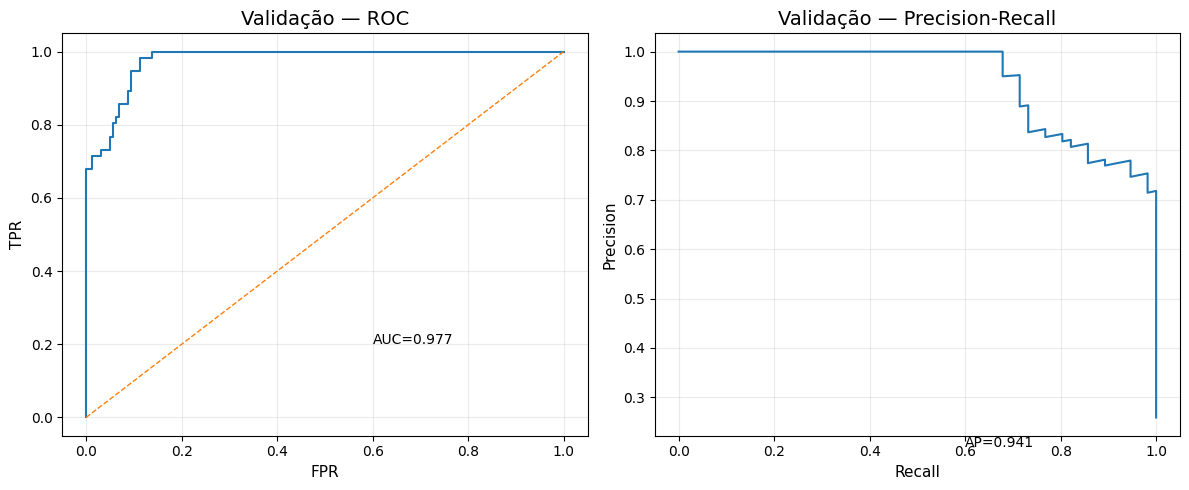

,thr,precision,recall,f1
0,0.10,0.259,1.000,0.412
1,0.15,0.259,1.000,0.412
2,0.20,0.259,1.000,0.412
3,0.25,0.259,1.000,0.412
4,0.30,0.262,1.000,0.415
5,0.35,0.263,1.000,0.416
6,0.40,0.281,1.000,0.439
7,0.45,0.327,1.000,0.493
8,0.50,0.415,1.000,0.586
9,0.55,0.483,1.000,0.651


In [49]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Pontos na validação
proba_val = chosen_model.predict_proba(X_valid)[:,1]
fpr, tpr, roc_thr = roc_curve(y_valid, proba_val)
prec, rec, pr_thr = precision_recall_curve(y_valid, proba_val)

plt.figure(figsize=(12,5))

# ROC
plt.subplot(1,2,1)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--',lw=1)
plt.title('Validação — ROC')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.text(0.6,0.2,f"AUC={roc_auc_score(y_valid, proba_val):.3f}")

# PR
plt.subplot(1,2,2)
plt.plot(rec, prec)
plt.title('Validação — Precision-Recall')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.text(0.6,0.2,f"AP={average_precision_score(y_valid, proba_val):.3f}")

plt.tight_layout(); plt.show()

# Tabela de limiares (para o anexo)
thr_grid = np.round(np.linspace(0.10,0.90,17), 2)
rows = []
for t in thr_grid:
    yhat = (proba_val>=t).astype(int)
    p,r,f = precision_recall_fscore_support(y_valid, yhat, average='binary', zero_division=0)[:3]
    rows.append({'thr':t,'precision':round(p,3),'recall':round(r,3),'f1':round(f,3)})
pd.DataFrame(rows)


In [50]:
def subgroup_report(df_base, y_true, yhat, group_col, X_index):
    tmp = df_base.loc[X_index, [group_col]].copy()
    tmp['y'] = y_true
    tmp['yhat'] = yhat
    out = []
    for g, d in tmp.groupby(group_col):
        p,r,f,_ = precision_recall_fscore_support(d['y'], d['yhat'], average='binary', zero_division=0)
        out.append({'grupo': g, 'n': len(d), 'precision': round(p,3), 'recall': round(r,3), 'f1': round(f,3)})
    return pd.DataFrame(out).sort_values('f1', ascending=False)

# Relatórios no TESTE
test_proba = chosen_model.predict_proba(X_test)[:,1]
yhat_test  = (test_proba >= chosen_thr).astype(int)

print("Por região (mapeie seu estado -> região):")
# Adicione um map estado→região antes:
state_to_region = {
    # Northeast
    'Maine':'NE','New Hampshire':'NE','Vermont':'NE','Massachusetts':'NE','Rhode Island':'NE','Connecticut':'NE',
    'New York':'NE','New Jersey':'NE','Pennsylvania':'NE',
    # Midwest
    'Ohio':'MW','Michigan':'MW','Indiana':'MW','Wisconsin':'MW','Illinois':'MW',
    'Minnesota':'MW','Iowa':'MW','Missouri':'MW','North Dakota':'MW','South Dakota':'MW','Nebraska':'MW','Kansas':'MW',
    # South
    'Delaware':'S','Maryland':'S','District Of Columbia':'S','Virginia':'S','West Virginia':'S','North Carolina':'S',
    'South Carolina':'S','Georgia':'S','Florida':'S','Kentucky':'S','Tennessee':'S','Mississippi':'S','Alabama':'S',
    'Oklahoma':'S','Texas':'S','Arkansas':'S','Louisiana':'S',
    # West
    'Idaho':'W','Montana':'W','Wyoming':'W','Nevada':'W','Utah':'W','Arizona':'W','Colorado':'W','New Mexico':'W',
    'Alaska':'W','Washington':'W','Oregon':'W','California':'W','Hawaii':'W',
    # Territories (agrupe como 'T')
    'Puerto Rico':'T','Virgin Islands':'T','Territories':'T'
}
tmp_base = base.copy()
tmp_base['region'] = tmp_base['Bene_Geo_Desc'].map(state_to_region).fillna('T')

display(subgroup_report(tmp_base, y_test.values, yhat_test, 'region', X_test.index))

print("Por RUCA (se tiver coluna RUCA no recorte; caso contrário, pule):")
# Se você quiser por RUCA, troque 'region' acima por 'Bene_RUCA_Desc' e gere outro report


Por região (mapeie seu estado -> região):


,grupo,n,precision,recall,f1
1,NE,9,0.667,1.0,0.800
0,MW,12,0.500,1.0,0.667
4,W,13,0.333,1.0,0.500
2,S,17,0.300,1.0,0.462
3,T,3,0.000,0.0,0.000


Por RUCA (se tiver coluna RUCA no recorte; caso contrário, pule):


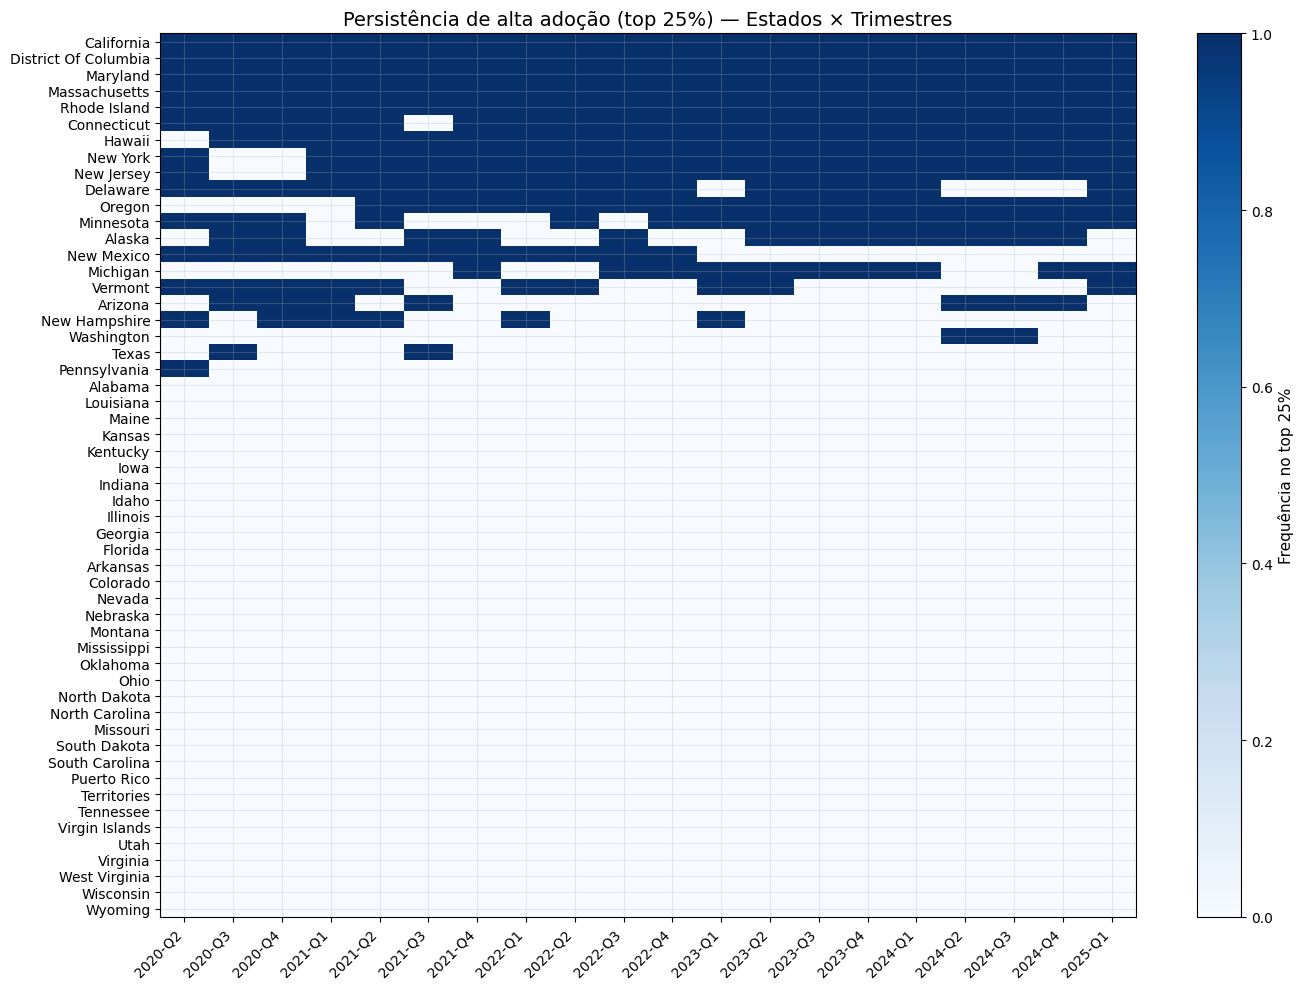

In [43]:
# Matriz estado x período (0/1), usando o rótulo 'y' que você criou
pivot = base.pivot_table(index='Bene_Geo_Desc', columns=['Year','quarter'], values='y', aggfunc='mean').fillna(0)
# Ordena por soma total (mais persistentes em cima)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(14,10))
plt.imshow(pivot.values, aspect='auto', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label='Frequência no top 25%')
plt.yticks(range(pivot.shape[0]), pivot.index)
plt.xticks(range(pivot.shape[1]), [f'{y}-Q{q}' for (y,q) in pivot.columns], rotation=45, ha='right')
plt.title('Persistência de alta adoção (top 25%) — Estados × Trimestres')
plt.tight_layout(); plt.show()


In [53]:
r = permutation_importance(chosen_model, X_valid, y_valid, n_repeats=20, random_state=42, scoring='f1')
imp = pd.DataFrame({'feature': features, 'importance_mean': r.importances_mean, 'importance_std': r.importances_std})\
        .sort_values('importance_mean', ascending=False)
imp


,feature,importance_mean,importance_std
3,pct_lag1,0.223706,0.037825
1,quarter,0.007931,0.007399
0,Year,0.000000,0.000000
2,elig_rate,-0.001260,0.004185


In [51]:
# Tabela final de métricas (validação e teste)
def metrics_table(model, thr, Xv, yv, Xt, yt):
    pv = model.predict_proba(Xv)[:,1]; yhv = (pv>=thr).astype(int)
    pt = model.predict_proba(Xt)[:,1]; yht = (pt>=thr).astype(int)
    def pack(y, p, yh):
        return {
            'AUC': round(roc_auc_score(y,p),3),
            'AP':  round(average_precision_score(y,p),3),
            'F1':  round(f1_score(y,yh),3),
            'Precision': round(precision_recall_fscore_support(y,yh, average="binary", zero_division=0)[0],3),
            'Recall':    round(precision_recall_fscore_support(y,yh, average="binary", zero_division=0)[1],3)
        }
    return pd.DataFrame([{'partição':'validação', **pack(yv,pv,yhv)},
                         {'partição':'teste',      **pack(yt,pt,yht)}])

metrics_table(chosen_model, chosen_thr, X_valid, y_valid, X_test, y_test)
# Se quiser: salvar com .to_csv('/mnt/data/metricas_finais.csv', index=False)



,partição,AUC,AP,F1,Precision,Recall
0,validação,0.977,0.941,0.836,0.718,1.0
1,teste,0.986,0.964,0.609,0.438,1.0


# Curva de calibração + “lift”

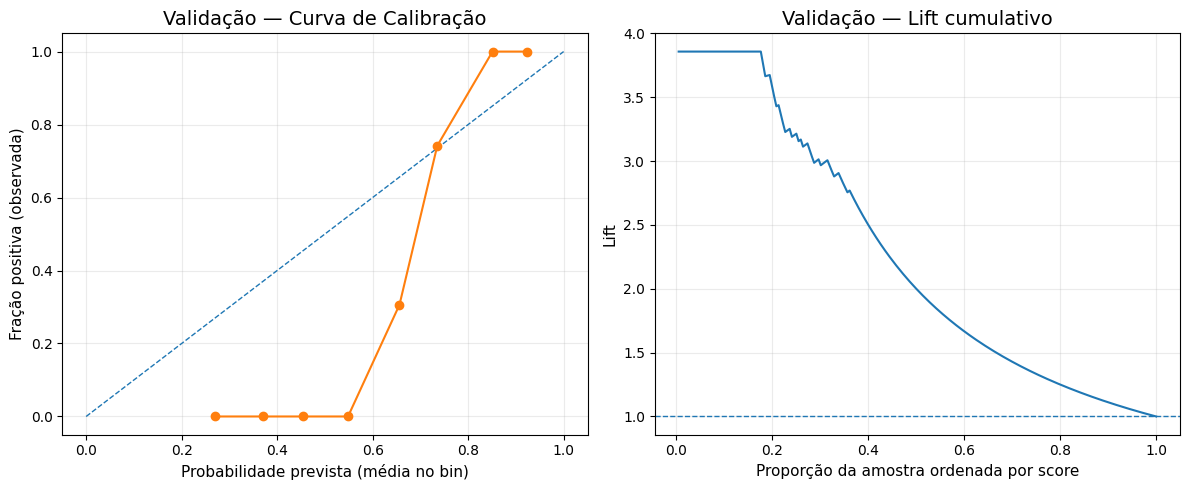

In [62]:
proba_val = chosen_model.predict_proba(X_valid)[:,1]
yhat_val  = (proba_val >= chosen_thr).astype(int)

# Calibração (bins=10)
frac_pos, mean_pred = calibration_curve(y_valid, proba_val, n_bins=10, strategy='uniform')

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot([0,1],[0,1],'--',lw=1)
plt.plot(mean_pred, frac_pos, marker='o')
plt.title('Validação — Curva de Calibração')
plt.xlabel('Probabilidade prevista (média no bin)')
plt.ylabel('Fração positiva (observada)')

# Lift (ganho sobre aleatório)
order = np.argsort(proba_val)[::-1]
y_sorted = y_valid.values[order]
cum_pos = np.cumsum(y_sorted)
perc = np.arange(1, len(y_sorted)+1) / len(y_sorted)
lift = (cum_pos / cum_pos[-1]) / perc

plt.subplot(1,2,2)
plt.plot(perc, lift)
plt.axhline(1.0, ls='--', lw=1)
plt.title('Validação — Lift cumulativo')
plt.xlabel('Proporção da amostra ordenada por score')
plt.ylabel('Lift')
plt.tight_layout(); plt.show()

In [63]:
tmp = tmp_base.loc[X_test.index, ['region']].copy()
tmp['y']    = y_test.values
tmp['yhat'] = yhat_test

rows = []
for g, d in tmp.groupby('region'):
    # força 2x2 mesmo quando só há uma classe no grupo
    cm = confusion_matrix(d['y'], d['yhat'], labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # métricas derivadas úteis (com proteção a divisão por zero)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = (2*precision*recall / (precision+recall)) if (precision+recall) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    bal_acc     = 0.5*(recall + specificity)

    rows.append({
        'region': g, 'n': len(d),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'precision': round(precision,3),
        'recall':    round(recall,3),
        'f1':        round(f1,3),
        'specificity': round(specificity,3),
        'balanced_acc': round(bal_acc,3),
    })

df_regions = pd.DataFrame(rows).sort_values('region')
df_regions


,region,n,TP,FP,FN,TN,precision,recall,f1,specificity,balanced_acc
0,MW,12,2,2,0,8,0.500,1.0,0.667,0.8,0.90
1,NE,9,6,3,0,0,0.667,1.0,0.800,0.0,0.50
2,S,17,3,7,0,7,0.300,1.0,0.462,0.5,0.75
3,T,3,0,0,0,3,0.000,0.0,0.000,1.0,0.50
4,W,13,3,6,0,4,0.333,1.0,0.500,0.4,0.70


In [64]:
Xtr_b, Xv_b, Xt_b = train[['pct_lag1']], valid[['pct_lag1']], test[['pct_lag1']]
logit_b = LogisticRegression(class_weight='balanced', solver='liblinear')
logit_b.fit(Xtr_b, y_train)

pv = logit_b.predict_proba(Xv_b)[:,1]
best_thr_b = np.linspace(0.1,0.9,17)[np.argmax([f1_score(y_valid,(pv>=t).astype(int)) for t in np.linspace(0.1,0.9,17)])]

pt = logit_b.predict_proba(Xt_b)[:,1]
yht = (pt >= best_thr_b).astype(int)

print("Baseline (lag1) — Val AUC/AP:", round(roc_auc_score(y_valid,pv),3), round(average_precision_score(y_valid,pv),3))
print("Baseline (lag1) — Teste AUC/AP:", round(roc_auc_score(y_test,pt),3), round(average_precision_score(y_test,pt),3))
print("Baseline (lag1) — Teste F1:", round(f1_score(y_test,yht),3), "thr=", round(float(best_thr_b),3))


Baseline (lag1) — Val AUC/AP: 0.988 0.963
Baseline (lag1) — Teste AUC/AP: 0.984 0.961
Baseline (lag1) — Teste F1: 0.778 thr= 0.4


In [65]:
# prevalência (taxa de positivos) e suporte por região — TESTE
tmp = tmp_base.loc[X_test.index, ['region']].copy()
tmp['y'] = y_test.values
prev = tmp.groupby('region')['y'].agg(['mean','count']).rename(columns={'mean':'prevalence','count':'n'})
prev['prevalence'] = prev['prevalence'].round(3)
prev.sort_values('prevalence', ascending=False)


,prevalence,n
region,,
NE,0.667,9
W,0.231,13
S,0.176,17
MW,0.167,12
T,0.000,3


In [68]:
# mapeia região também na validação
val_map = tmp_base.loc[X_valid.index, ['region']].copy()

thr_grid = np.linspace(0.10, 0.90, 17)
proba_val = chosen_model.predict_proba(X_valid)[:,1]
proba_tst = chosen_model.predict_proba(X_test)[:,1]

best_thr_by_region = {}
for reg, dv in val_map.assign(y=y_valid.values, p=proba_val).groupby('region'):
    # escolhe t que maximiza F1 na validação daquele grupo
    f1s = []
    for t in thr_grid:
        yhat = (dv['p'].values >= t).astype(int)
        f1s.append(f1_score(dv['y'].values, yhat) if dv['y'].nunique()>1 else 0.0)
    best_thr_by_region[reg] = float(thr_grid[int(np.argmax(f1s))])

# aplica no TESTE e calcula métricas por região
rows = []
tst = tmp_base.loc[X_test.index, ['region']].copy()
tst['y'] = y_test.values
tst['p'] = proba_tst
for reg, dt in tst.groupby('region'):
    thr = best_thr_by_region.get(reg, chosen_thr)
    yhat = (dt['p'].values >= thr).astype(int)
    p = precision_score(dt['y'], yhat, zero_division=0)
    r = recall_score(dt['y'], yhat, zero_division=0)
    f = f1_score(dt['y'], yhat, zero_division=0)
    rows.append({'region': reg, 'n': len(dt), 'thr*': round(thr,2),
                 'precision': round(p,3), 'recall': round(r,3), 'f1': round(f,3)})
pd.DataFrame(rows).sort_values('region')


,region,n,thr*,precision,recall,f1
0,MW,12,0.65,0.500,1.0,0.667
1,NE,9,0.70,0.750,1.0,0.857
2,S,17,0.75,0.600,1.0,0.750
3,T,3,0.10,0.000,0.0,0.000
4,W,13,0.65,0.333,1.0,0.500
